In [7]:
# imports

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import torch
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score
from torch.utils.data import DataLoader
from torchvision import transforms

In [15]:
# load dataset

from src.datasets_mask_crop import HAMMaskCropDataset
from src.train_resnet_mask_crop import MultiModalResNet

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path("../data/processed")

In [16]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
# load val data

val_dataset = HAMMaskCropDataset(
    DATA_DIR / "val_with_bboxes.csv",
    transform=val_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [18]:
# load model

meta_dim = len(val_dataset.meta_cols)

model = MultiModalResNet(meta_input_dim=meta_dim).to(DEVICE)
model.load_state_dict(
    torch.load(DATA_DIR / "best_resnet_mask_crop.pth", map_location=DEVICE)
)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


/tmp/ipykernel_219294/1737489895.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(DATA_DIR / "best_resnet_mask_crop.pth", map_location=DEVICE)


In [20]:
# run inference

from tqdm.asyncio import tqdm


all_preds = []
all_labels = []

with torch.no_grad():
    for images, metadata, labels in tqdm(val_loader):
        images = images.to(DEVICE)
        metadata = metadata.to(DEVICE)

        outputs = model(images, metadata)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

100%|██████████| 64/64 [00:12<00:00,  5.07it/s]


In [21]:
# compute metrics 

accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

report = classification_report(all_labels, all_preds, output_dict=True)
pd.DataFrame(report).transpose()

Accuracy: 0.7731504164625184
Macro F1: 0.7189527115042315
Weighted F1: 0.7884439959196858


,precision,recall,f1-score,support
0,0.602564,0.691176,0.643836,68.00000
1,0.753247,0.878788,0.811189,132.00000
2,0.702479,0.696721,0.699588,244.00000
3,0.769231,0.588235,0.666667,34.00000
4,0.400000,0.711111,0.512000,225.00000
5,0.940693,0.791859,0.859883,1302.00000
6,0.755556,0.944444,0.839506,36.00000
accuracy,0.773150,0.773150,0.773150,0.77315
macro avg,0.703396,0.757476,0.718953,2041.00000
weighted avg,0.823099,0.773150,0.788444,2041.00000


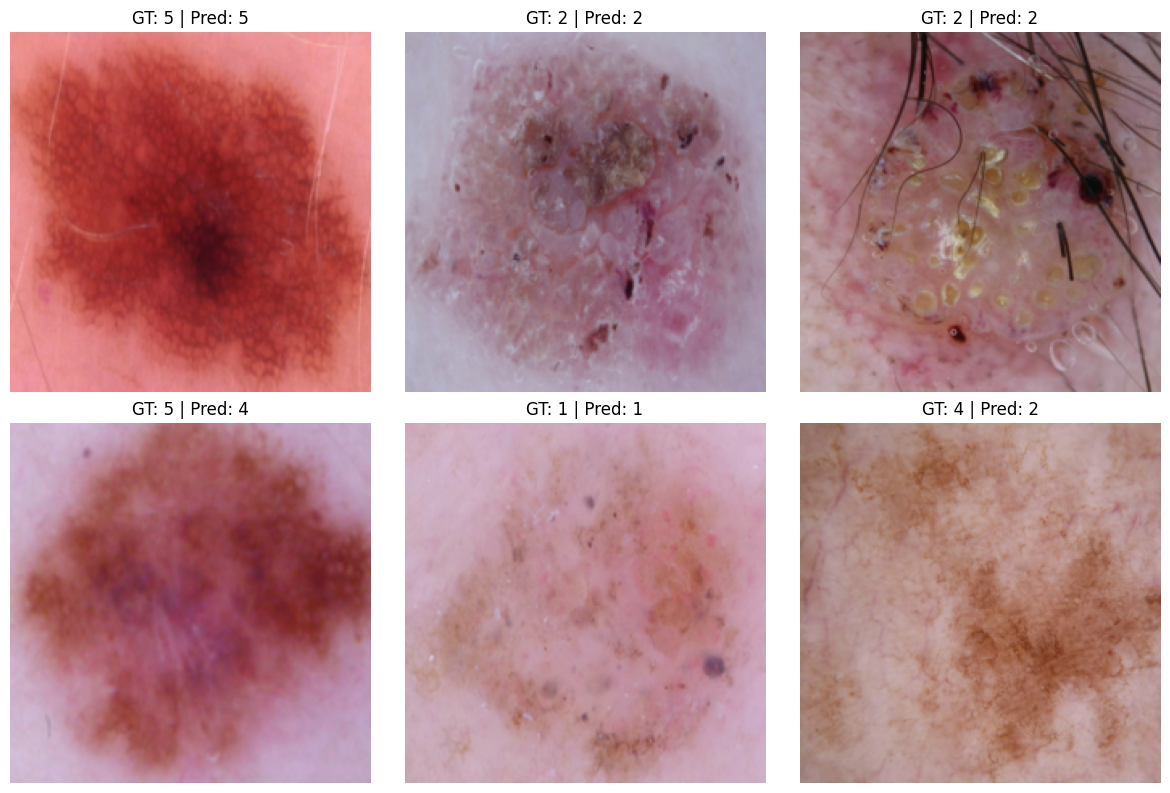

In [22]:
import matplotlib.pyplot as plt
import random

# Select random samples
indices = random.sample(range(len(val_dataset)), 6)

model.eval()

fig, axes = plt.subplots(2, 3, figsize=(12,8))

for ax, idx in zip(axes.flatten(), indices):
    image, metadata, label = val_dataset[idx]
    
    input_image = image.unsqueeze(0).to(DEVICE)
    metadata = metadata.unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        output = model(input_image, metadata)
        pred = torch.argmax(output, dim=1).item()
    
    # Undo normalization for display
    img_np = image.permute(1,2,0).cpu().numpy()
    img_np = (img_np * [0.229,0.224,0.225]) + [0.485,0.456,0.406]
    img_np = np.clip(img_np, 0, 1)

    ax.imshow(img_np)
    ax.set_title(f"GT: {label.item()} | Pred: {pred}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
# save results

results_path = Path("../results/experiments.csv")

row = {
    "model_name": "resnet34_mask_crop",
    "accuracy": accuracy,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
}

# Add class-wise metrics
for cls in report:
    if cls.isdigit():
        row[f"class_{cls}_precision"] = report[cls]["precision"]
        row[f"class_{cls}_recall"] = report[cls]["recall"]
        row[f"class_{cls}_f1"] = report[cls]["f1-score"]
        row[f"class_{cls}_support"] = report[cls]["support"]

df = pd.DataFrame([row])

if results_path.exists():
    df.to_csv(results_path, mode="a", header=False, index=False)
else:
    df.to_csv(results_path, index=False)

print("Mask-crop results saved.")

Mask-crop results saved.
